# Customer Churn Prediction System
### Phase 2: Data Cleaning & Exploratory Data Analysis (Tasks 3-7)

This picks up right after Phase 1. We already know the dataset is clean (0 missing
values, 0 duplicates) and the target is reasonably balanced (52.6% stayed / 47.4%
churned). This phase is about actually *looking* at the data to find which features
matter before we build any model.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('customer_churn.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 64374 rows, 12 columns


## Task 3: Data Cleaning

Two things to do here:
1. Drop `CustomerID` — it's just a label with no predictive meaning.
2. Sanity-check every numeric column for impossible values (negative ages, negative
   payment delays, etc.) — this is what "cleaning" actually means when the dataset
   has no missing values or duplicates to begin with.

In [5]:
# Drop CustomerID — it carries no behavioral signal, just an identifier
df = df.drop(columns=['CustomerID'])
print(f"Dropped CustomerID. Working shape: {df.shape}")
df.head()

Dropped CustomerID. Working shape: (64374, 11)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [6]:
numeric_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
                'Payment Delay', 'Total Spend', 'Last Interaction']

print("Sanity check — min and max for every numeric column:\n")
for col in numeric_cols:
    print(f"{col:20s} min={df[col].min():>8.1f}   max={df[col].max():>8.1f}")

Sanity check — min and max for every numeric column:

Age                  min=    18.0   max=    65.0
Tenure               min=     1.0   max=    60.0
Usage Frequency      min=     1.0   max=    30.0
Support Calls        min=     0.0   max=    10.0
Payment Delay        min=     0.0   max=    30.0
Total Spend          min=   100.0   max=  1000.0
Last Interaction     min=     1.0   max=    30.0


**Result:** every range looks realistic — `Age` is 18 to 65 (real adult customers),
none of the count/day columns (`Support Calls`, `Payment Delay`, `Tenure`, `Usage
Frequency`, `Last Interaction`) go negative, and `Total Spend` stays within a sane
100–1000 range. There's nothing to fix — the dataset was already clean going in.
This is unusual for real-world data, but it means we can move straight to analysis
without writing imputation or outlier-removal logic.

## Task 4: Exploratory Data Analysis (EDA)

For every numeric feature, we plot its distribution **split by Churn** (0 = stayed,
1 = churned) using box plots. If a feature's box for churned customers sits in a
clearly different place than for non-churned customers, that's a visual signal the
feature is useful for prediction. If the two boxes overlap almost entirely, the
feature probably won't help the model much on its own.

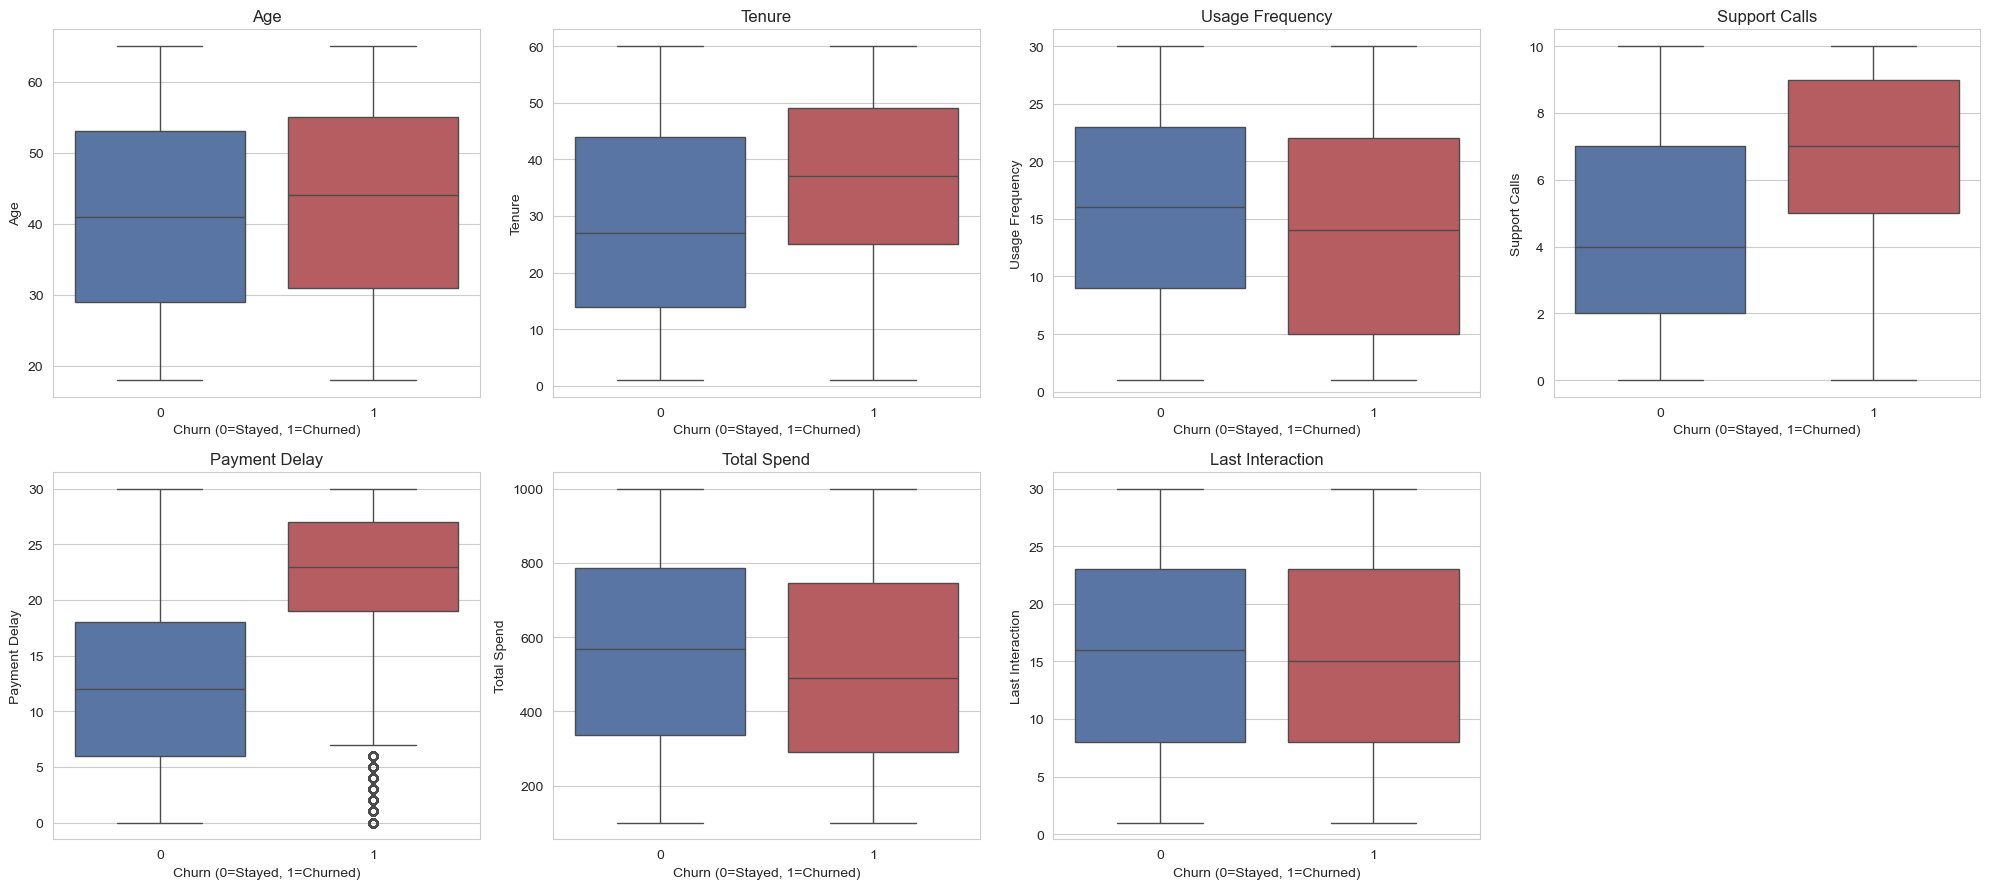

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], hue='Churn', legend=False,
                palette={0: '#4C72B0', 1: '#C44E52'})
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Churn (0=Stayed, 1=Churned)')

# Hide the unused 8th subplot
axes[7].axis('off')

plt.tight_layout()
plt.show()

**How to read this:** look for features where the blue box (stayed) and red box
(churned) sit at clearly different heights. `Support Calls` and `Payment Delay`
should stand out immediately — churned customers cluster much higher on both. Most
of the other features (`Age`, `Usage Frequency`, `Total Spend`, `Last Interaction`)
show heavy overlap between the two groups, meaning they're weaker predictors on
their own. We'll confirm this numerically in Task 6.

## Task 5: Behavior Pattern Analysis

Task 4 gave us a visual first pass. Now we test specific business questions directly
by computing the **churn rate** (fraction of customers who churned) at each level of
a feature, rather than just eyeballing box plots.

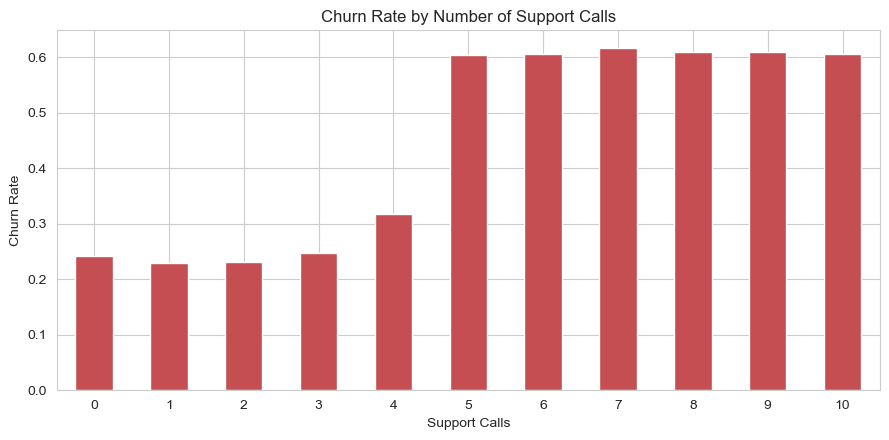

Support Calls
0     0.242
1     0.229
2     0.232
3     0.248
4     0.318
5     0.605
6     0.606
7     0.618
8     0.610
9     0.609
10    0.607
Name: Churn, dtype: float64


In [9]:
# Does more support calls mean higher churn?
support_churn = df.groupby('Support Calls')['Churn'].mean()

plt.figure(figsize=(9, 4.5))
support_churn.plot(kind='bar', color='#C44E52')
plt.title('Churn Rate by Number of Support Calls')
plt.xlabel('Support Calls')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(support_churn.round(3))

**Finding:** churn rate sits around **23–32%** for customers with 0–4 support
calls, then **jumps to roughly 60%** for 5 or more calls. This isn't a gradual
slope — it's a sharp threshold around 5 calls. That's a strong, actionable signal:
5+ support calls is a red flag worth building an alert around in a real business.

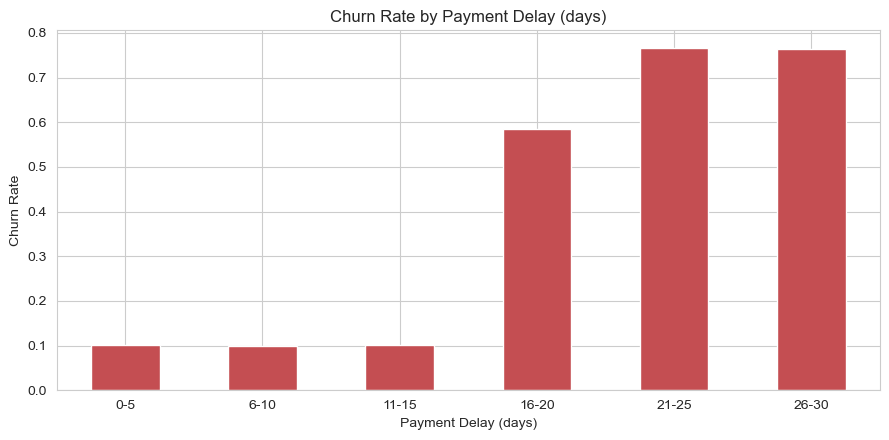

Payment Delay Range
0-5      0.102
6-10     0.099
11-15    0.102
16-20    0.586
21-25    0.767
26-30    0.764
Name: Churn, dtype: float64


In [10]:
# Does longer payment delay mean higher churn?
df['Payment Delay Range'] = pd.cut(df['Payment Delay'],
                                    bins=[-1, 5, 10, 15, 20, 25, 30],
                                    labels=['0-5', '6-10', '11-15', '16-20', '21-25', '26-30'])
delay_churn = df.groupby('Payment Delay Range', observed=True)['Churn'].mean()

plt.figure(figsize=(9, 4.5))
delay_churn.plot(kind='bar', color='#C44E52')
plt.title('Churn Rate by Payment Delay (days)')
plt.xlabel('Payment Delay (days)')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(delay_churn.round(3))

**Finding:** an even sharper threshold. Churn rate holds around **10%** for delays
up to 15 days, then **jumps to 58–77%** past 15 days. `Payment Delay` looks like it
will end up being the single strongest predictor in this dataset — we'll verify that
with actual numbers in Task 6.

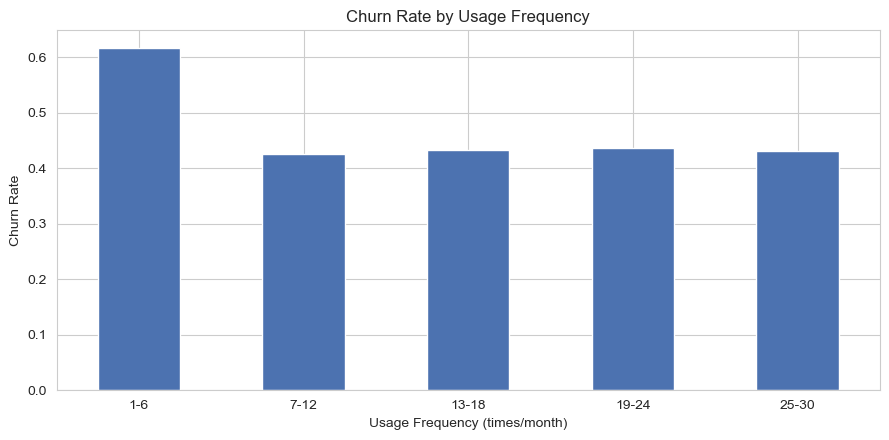

Usage Range
1-6      0.618
7-12     0.426
13-18    0.433
19-24    0.437
25-30    0.431
Name: Churn, dtype: float64


In [11]:
# Does usage frequency relate to churn?
df['Usage Range'] = pd.cut(df['Usage Frequency'], bins=[0, 6, 12, 18, 24, 30],
                            labels=['1-6', '7-12', '13-18', '19-24', '25-30'])
usage_churn = df.groupby('Usage Range', observed=True)['Churn'].mean()

plt.figure(figsize=(9, 4.5))
usage_churn.plot(kind='bar', color='#4C72B0')
plt.title('Churn Rate by Usage Frequency')
plt.xlabel('Usage Frequency (times/month)')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(usage_churn.round(3))

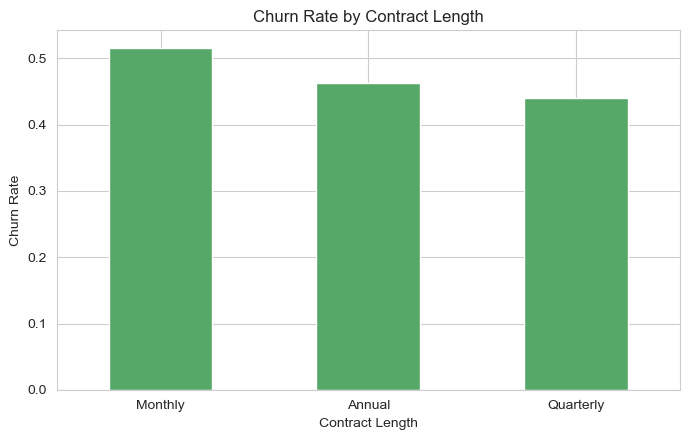

Contract Length
Monthly      0.516
Annual       0.462
Quarterly    0.440
Name: Churn, dtype: float64


In [12]:
# Does contract length relate to churn?
contract_churn = df.groupby('Contract Length')['Churn'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4.5))
contract_churn.plot(kind='bar', color='#55A868')
plt.title('Churn Rate by Contract Length')
plt.xlabel('Contract Length')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(contract_churn.round(3))

**Findings so far:**
- **Usage Frequency** shows only a mild, inconsistent relationship with churn — not
  a strong standalone predictor.
- **Contract Length** shows a real but modest gap: Monthly customers churn the most
  (~52%), Quarterly the least (~44%), Annual in between (~46%). Makes business
  sense — customers on short commitments have less friction to leave.

## Task 6: Correlation Analysis

Now we quantify everything at once with a correlation matrix. Correlation ranges
from -1 to +1: values near +1 or -1 mean a strong relationship, values near 0 mean
almost no linear relationship. We temporarily encode `Gender` as a number here
purely to include it in this matrix — the real encoding for modeling happens in
Phase 3.

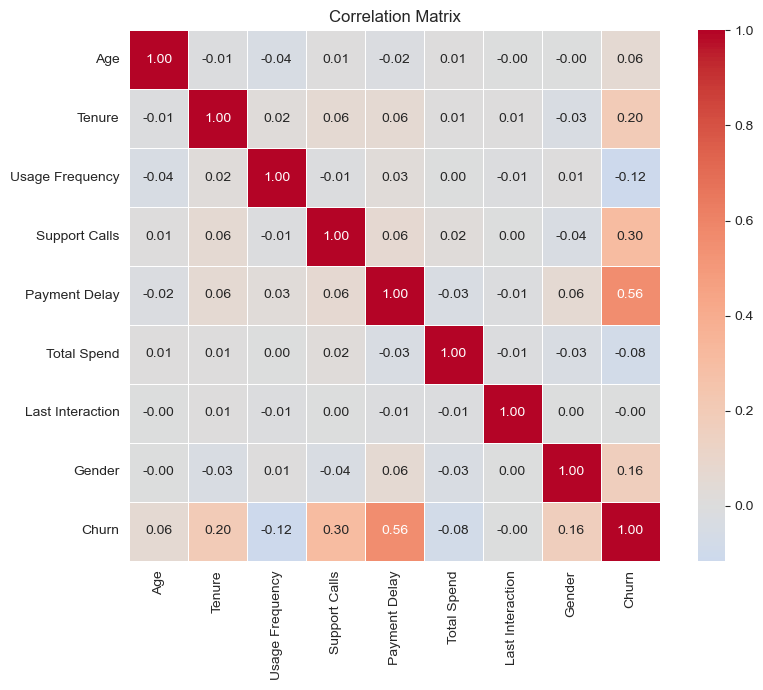

In [13]:
corr_df = df[numeric_cols + ['Gender', 'Churn']].copy()
corr_df['Gender'] = corr_df['Gender'].map({'Male': 0, 'Female': 1})

corr_matrix = corr_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [14]:
# Which features correlate most strongly with Churn specifically?
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(ascending=False)
print("Correlation with Churn (sorted):\n")
print(churn_corr.round(3))

Correlation with Churn (sorted):

Payment Delay       0.557
Support Calls       0.305
Tenure              0.195
Gender              0.165
Age                 0.063
Last Interaction   -0.003
Total Spend        -0.079
Usage Frequency    -0.115
Name: Churn, dtype: float64


**Findings (this is the most important table in this phase):**
- **`Payment Delay` (≈ +0.56)** and **`Support Calls` (≈ +0.30)** are by far the
  strongest predictors — this matches exactly what we found visually in Task 5.
- **`Tenure` (≈ +0.20)** and **`Gender` (≈ +0.16)** have a moderate relationship.
- **`Age` (≈ +0.06)**, **`Last Interaction` (≈ 0.00)**, **`Total Spend` (≈ -0.08)**,
  and **`Usage Frequency` (≈ -0.12)** are all weak — they likely won't drive
  predictions much on their own, though a model like Random Forest can still combine
  them with other features in useful ways.
- No two features are so strongly correlated *with each other* that we need to worry
  about redundancy going into modeling.

## Task 7: Categorical Analysis

We now do the same churn-rate comparison for the three categorical columns:
`Gender`, `Subscription Type`, and `Contract Length`.

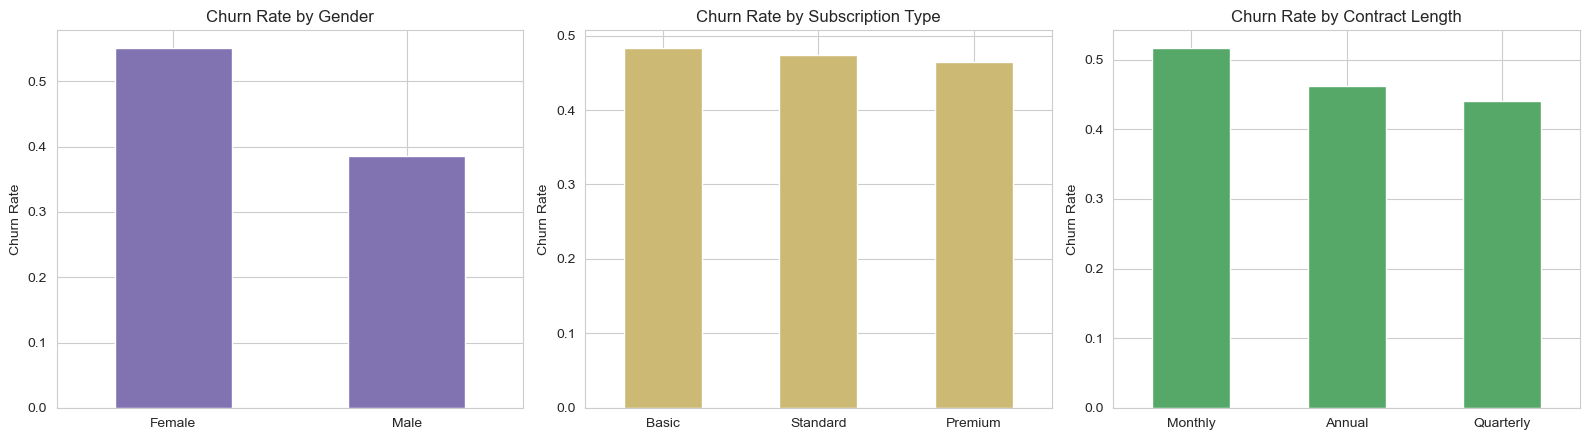


Gender:
Gender
Female    0.550
Male      0.386
Name: Churn, dtype: float64

Subscription Type:
Subscription Type
Basic       0.483
Standard    0.473
Premium     0.465
Name: Churn, dtype: float64

Contract Length:
Contract Length
Monthly      0.516
Annual       0.462
Quarterly    0.440
Name: Churn, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col, color in zip(
    axes,
    ['Gender', 'Subscription Type', 'Contract Length'],
    ['#8172B2', '#CCB974', '#55A868']
):
    rates = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color=color)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

for col in ['Gender', 'Subscription Type', 'Contract Length']:
    print(f"\n{col}:")
    print(df.groupby(col)['Churn'].mean().round(3).sort_values(ascending=False))

**Findings:**
- **Gender shows the biggest gap of the three**: Female customers churn at about
  **55%** vs Male at about **39%** — a meaningfully large difference worth flagging
  in your write-up.
- **Subscription Type is nearly flat** (Basic ≈48%, Standard ≈47%, Premium ≈47%) —
  the plan tier itself barely matters for churn.
- **Contract Length** confirms Task 5: Monthly customers churn most, Quarterly
  least.

---
### ✅ Phase 2 checkpoint — what we now know about this dataset

1. **Data was already clean** — dropping `CustomerID` was the only real cleaning step.
2. **`Payment Delay` and `Support Calls` are the dominant predictors**, both with
   clear thresholds (15+ days delay, 5+ support calls) where churn risk jumps
   sharply rather than climbing gradually.
3. **`Gender` and `Contract Length`** show real but smaller effects.
4. **`Age`, `Usage Frequency`, `Total Spend`, `Last Interaction`, and `Subscription
   Type`** are weak standalone predictors.

This directly sets up what to expect in **Task 14 (feature importance)** later — if
the trained model doesn't rank `Payment Delay` and `Support Calls` near the top,
that would be worth investigating.

**Next: Phase 3 (Tasks 8-10)** — splitting the data into features/target, doing the
train-test split, and encoding + scaling everything so it's actually ready for a
machine learning model.